# S&P 500 动量因子选股 v2

**目标**: 用纯量价动量特征 + LightGBM 在 S&P 500 中预测未来 10 天残差收益率，选出 top 10 股票等权持有。

**v2 特征体系**: 5 组 25 个纯量价特征（基础动量、skip 动量、路径质量、风险调整动量、量价交互）

**设计原则**:
- 不加入行业等非量价信息，确保评估的是纯量价因子的预测力
- 只做一次 cross-sectional rank，不做 sector neutralize
- 标签用原始残差收益（不 rank）

**已知偏差**:
- 使用当前 S&P 500 成分股，存在 survivorship bias
- 残差收益用 β-adjusted: `r_stock - β × r_SPY`

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from equity.data import get_sp500_tickers, download_stock_data, load_universe, load_spy
from equity.features import compute_all_features, cross_sectional_rank
from equity.labels import make_labels
from equity.model import run_cv_pipeline
from equity.backtest import backtest_topN, compute_daily_returns
from equity.analysis import (
    summary_metrics, print_metrics,
    calc_ic_series, quantile_analysis,
    plot_equity_curve, plot_ic_analysis, plot_quantile_returns, plot_feature_importance,
)

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. 数据下载

下载 S&P 500 全部成分股 + SPY 的日线 OHLCV（2015-2026）。首次运行需要几分钟，之后从 parquet 缓存加载。

In [2]:
tickers = get_sp500_tickers()
print(f"S&P 500 tickers: {len(tickers)}")
print(f"Sample: {tickers[:10]}")

download_stock_data(tickers, start="2015-01-01", end="2026-04-01", cache_dir="../data/equity")

S&P 500 tickers: 503
Sample: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']
All 504 tickers already cached.


In [3]:
# 加载数据
panel = load_universe(cache_dir="../data/equity", min_history_days=252)
spy = load_spy(cache_dir="../data/equity")

n_stocks = panel.index.get_level_values("ticker").nunique()
date_range = panel.index.get_level_values("date")
print(f"Universe: {n_stocks} stocks")
print(f"Date range: {date_range.min().date()} to {date_range.max().date()}")
print(f"Total rows: {len(panel):,}")
print(f"\nSPY: {len(spy)} days")
print(f"\nSample:")
panel.head()

Universe: 502 stocks
Date range: 2015-01-02 to 2026-03-31
Total rows: 1,375,458

SPY: 2827 days

Sample:


Price                   open       high        low      close       volume
date       ticker                                                         
2015-01-02 A       37.535488  37.653983  36.797173  36.970360    1529200.0
           AAPL    24.671145  24.682220  23.776348  24.214888  212818400.0
           ABBV    41.470293  42.078659  41.470293  41.755463    5086100.0
           ABT     36.517570  36.678974  36.025289  36.235115    3216600.0
           ACGL    18.764398  18.884845  18.472788  18.539352    1101600.0

## 2. 特征工程

5 组 ~25 个纯量价特征，每组对应一个独立假说：
1. **基础动量** (5): 不同窗口的过去收益 — 谁最近更强
2. **Skip 动量** (3): 去掉近期反转噪音 — 可延续的趋势
3. **路径质量** (6): 效率比、涨跌天数、收益集中度、回撤 — 动量是平滑还是乱冲
4. **风险调整动量** (4): return/vol、slope/RMSE — 单位风险下的强度
5. **量价交互** (7): 异常成交量、量价确认/背离、放量反转 — 成交量确认了还是否定了价格信号

变换：只做一次 cross-sectional rank。不加入行业等非量价信息。

In [4]:
%%time
raw_features = compute_all_features(panel)
print(f"Raw features shape: {raw_features.shape}")
print(f"Feature columns ({len(raw_features.columns)}):")
for i, col in enumerate(raw_features.columns):
    print(f"  {i+1:2d}. {col}")

Raw features shape: (1375458, 25)
Feature columns (25):
   1. ret_5d
   2. ret_10d
   3. ret_20d
   4. ret_60d
   5. ret_120d
   6. skip5_ret_20d
   7. skip5_ret_60d
   8. skip20_ret_120d
   9. efficiency_20d
  10. efficiency_60d
  11. up_ratio_20d
  12. ret_concentration_20d
  13. max_dd_20d
  14. dist_high_60d
  15. ret_vol_20d
  16. ret_vol_60d
  17. slope_rmse_20d
  18. slope_rmse_60d
  19. abnormal_vol_5d
  20. abnormal_vol_20d
  21. vwap_ret_20d
  22. vwap_ret_60d
  23. up_vol_ratio_20d
  24. reversal_vol_5d
  25. vol_price_corr_20d
CPU times: user 30.5 s, sys: 171 ms, total: 30.6 s
Wall time: 30.6 s


In [ ]:
%%time
# Cross-sectional rank only — no sector, no neutralization
features = cross_sectional_rank(raw_features)

print(f"Ranked features shape: {features.shape}")
print(f"Value range: [{features.min().min():.3f}, {features.max().max():.3f}]")
print(f"\nNaN ratio per feature:")
print((features.isna().sum() / len(features)).describe())

## 3. 标签构造

未来 10 天 beta-adjusted 残差收益率。

**v2 改动**: 不做 rank 变换，直接用原始残差收益作为回归标签。
v1 把标签 rank 到 [0,1] 后模型预测全部集中在 ~0.5（无区分力）。
原始残差虽然噪音大（std ~5.4%），但保留了收益幅度信息，
让模型可以区分"强 alpha"和"弱 alpha"。

In [6]:
%%time
# Raw beta-adjusted residual return labels (NOT ranked)
labels = make_labels(panel, spy, periods=10, beta_window=252)
print(f"Labels shape: {labels.shape}")
print(f"NaN ratio: {labels.isna().mean():.3f}")
print(f"\nLabel distribution:")
print(labels.dropna().describe())

Labels shape: (1375458,)
NaN ratio: 0.050

Label distribution:
count    1.307186e+06
mean     9.836761e-04
std      5.424368e-02
min     -7.833699e-01
25%     -2.649492e-02
50%      3.064195e-04
75%      2.715335e-02
max      1.781302e+00
Name: label, dtype: float64
CPU times: user 1.13 s, sys: 30 ms, total: 1.16 s
Wall time: 1.15 s


## 4. 单特征 IC 预检

每个特征单独与未来 10 天残差收益的 Spearman 相关（截面 IC）。
用 ranked features vs raw labels，和最终模型输入一致。

In [ ]:
from scipy import stats

# Align features and labels
common_idx = features.index.intersection(labels.dropna().index)
feat_aligned = features.loc[common_idx]
lab_aligned = labels.loc[common_idx]

# Compute mean IC for each feature
feature_ics = {}
for col in feat_aligned.columns:
    valid = feat_aligned[col].notna() & lab_aligned.notna()
    if valid.sum() < 1000:
        continue
    
    ic_daily_data = feat_aligned.loc[valid, [col]].copy()
    ic_daily_data["label"] = lab_aligned.loc[valid]
    
    daily_ic = ic_daily_data.groupby(level="date").apply(
        lambda g: stats.spearmanr(g.iloc[:, 0], g["label"])[0] if len(g) > 10 else np.nan
    )
    feature_ics[col] = {
        "mean_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0,
        "pct_positive": (daily_ic > 0).mean(),
    }

ic_df = pd.DataFrame(feature_ics).T.sort_values("mean_ic", ascending=False)
print(f"Feature IC summary ({len(ic_df)} features):\n")
print(ic_df.to_string(float_format="{:.4f}".format))

## 5. 模型训练 — LightGBM + Purged CV

纯量价特征，无行业信息。标签直接用原始残差收益（不 rank）。

In [ ]:
%%time
predictions, models = run_cv_pipeline(
    features=features,
    labels=labels,
    raw_labels=labels,
    n_splits=5,
    train_days=500,
    test_days=60,
    purge_days=10,
    embargo_days=5,
)
print(f"\nOOS predictions: {len(predictions):,} samples")
print(f"Date range: {predictions.index.get_level_values('date').min().date()} "
      f"to {predictions.index.get_level_values('date').max().date()}")
print(f"\nPrediction distribution:")
print(predictions["prediction"].describe())
predictions.head()

## 6. IC 分析

Information Coefficient = 每日预测值与实际残差收益的 Spearman 相关。
- Mean IC > 0.02 → 微弱信号
- ICIR > 0.5 → 信号稳定

Mean IC:  0.0107
IC Std:   0.1144
ICIR:     0.0933
IC > 0:   52.3%


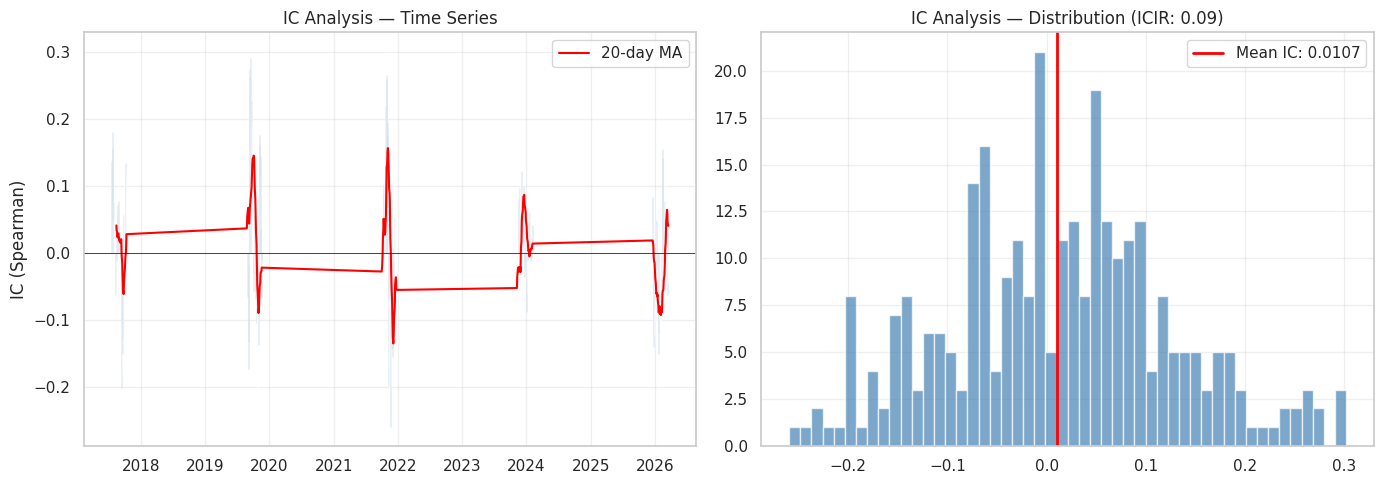

In [9]:
ic_series = calc_ic_series(predictions)
print(f"Mean IC:  {ic_series.mean():.4f}")
print(f"IC Std:   {ic_series.std():.4f}")
print(f"ICIR:     {ic_series.mean() / ic_series.std():.4f}")
print(f"IC > 0:   {(ic_series > 0).mean():.1%}")

plot_ic_analysis(ic_series)
plt.savefig("../output/equity_ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 分层回测（Quantile Analysis）

按预测值分 5 组，如果模型有效，Q5（最高预测值）应该收益最高，Q1 最低，呈单调递增。

Annualized mean return by quintile:
quantile
1   56.62%
2    8.96%
3   82.81%
4   59.42%
5   30.95%

Q5 - Q1 spread: -25.67% annualized


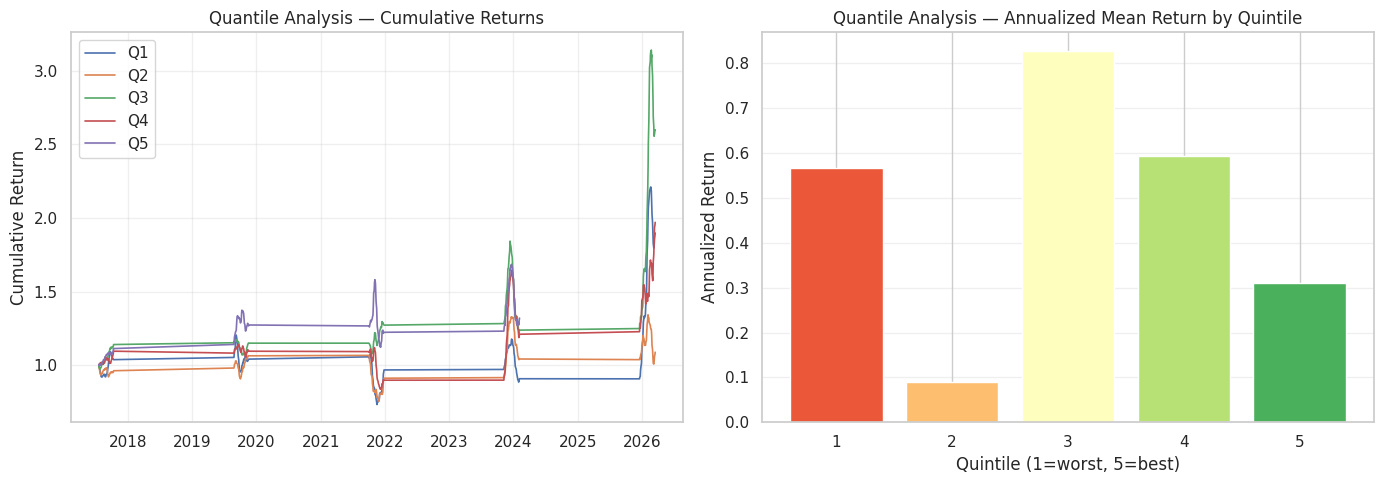

In [10]:
q_returns = quantile_analysis(predictions, n_groups=5)
print("Annualized mean return by quintile:")
print((q_returns.mean() * 252).to_string(float_format="{:.2%}".format))
print(f"\nQ5 - Q1 spread: {(q_returns[5].mean() - q_returns[1].mean()) * 252:.2%} annualized")

plot_quantile_returns(q_returns)
plt.savefig("../output/equity_quantile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 回测 — Top 10 / 20 / 30 对比

同时看多个 top-N，判断信号稳定性：
- 如果只有 top-5 好而 top-20 差 → 排序头部噪音，不可靠
- 如果 top-5/10/20 都有超额 → 信号有区分力

In [11]:
# Compute daily returns for backtest (raw returns, not residual)
daily_returns = compute_daily_returns(panel)

# SPY benchmark
spy_daily_ret = spy["close"].pct_change()

# Run backtest for multiple top-N values
for top_n in [10, 20, 30]:
    bt = backtest_topN(
        predictions=predictions,
        returns=daily_returns,
        top_n=top_n,
        rebalance_days=10,
        cost_bps=10,
    )
    
    spy_ret = spy_daily_ret.reindex(bt.index).fillna(0)
    strat = summary_metrics(bt["portfolio_return"])
    bench = summary_metrics(spy_ret)
    
    print(f"=== Top {top_n} (10-day rebalance, 10bps cost) ===")
    print(f"  Annual Return:    {strat['annual_return']:>8.2%}  (SPY: {bench['annual_return']:.2%})")
    print(f"  Sharpe:           {strat['sharpe_ratio']:>8.2f}  (SPY: {bench['sharpe_ratio']:.2f})")
    print(f"  Max Drawdown:     {strat['max_drawdown']:>8.2%}  (SPY: {bench['max_drawdown']:.2%})")
    print(f"  Excess Return:    {strat['annual_return'] - bench['annual_return']:>8.2%}")
    print(f"  Avg Turnover:     {bt['turnover'][bt['turnover'] > 0].mean():>8.1%}")
    print()

# Keep top-10 for detailed analysis
bt_results = backtest_topN(
    predictions=predictions,
    returns=daily_returns,
    top_n=10,
    rebalance_days=10,
    cost_bps=10,
)

=== Top 10 (10-day rebalance, 10bps cost) ===
  Annual Return:      44.73%  (SPY: 34.81%)
  Sharpe:               1.91  (SPY: 3.20)
  Max Drawdown:      -13.29%  (SPY: -4.77%)
  Excess Return:       9.92%
  Avg Turnover:        61.0%

=== Top 20 (10-day rebalance, 10bps cost) ===
  Annual Return:      54.63%  (SPY: 34.81%)
  Sharpe:               2.97  (SPY: 3.20)
  Max Drawdown:       -9.66%  (SPY: -4.77%)
  Excess Return:      19.82%
  Avg Turnover:        61.5%

=== Top 30 (10-day rebalance, 10bps cost) ===
  Annual Return:      45.09%  (SPY: 34.81%)
  Sharpe:               2.74  (SPY: 3.20)
  Max Drawdown:       -9.46%  (SPY: -4.77%)
  Excess Return:      10.28%
  Avg Turnover:        64.1%



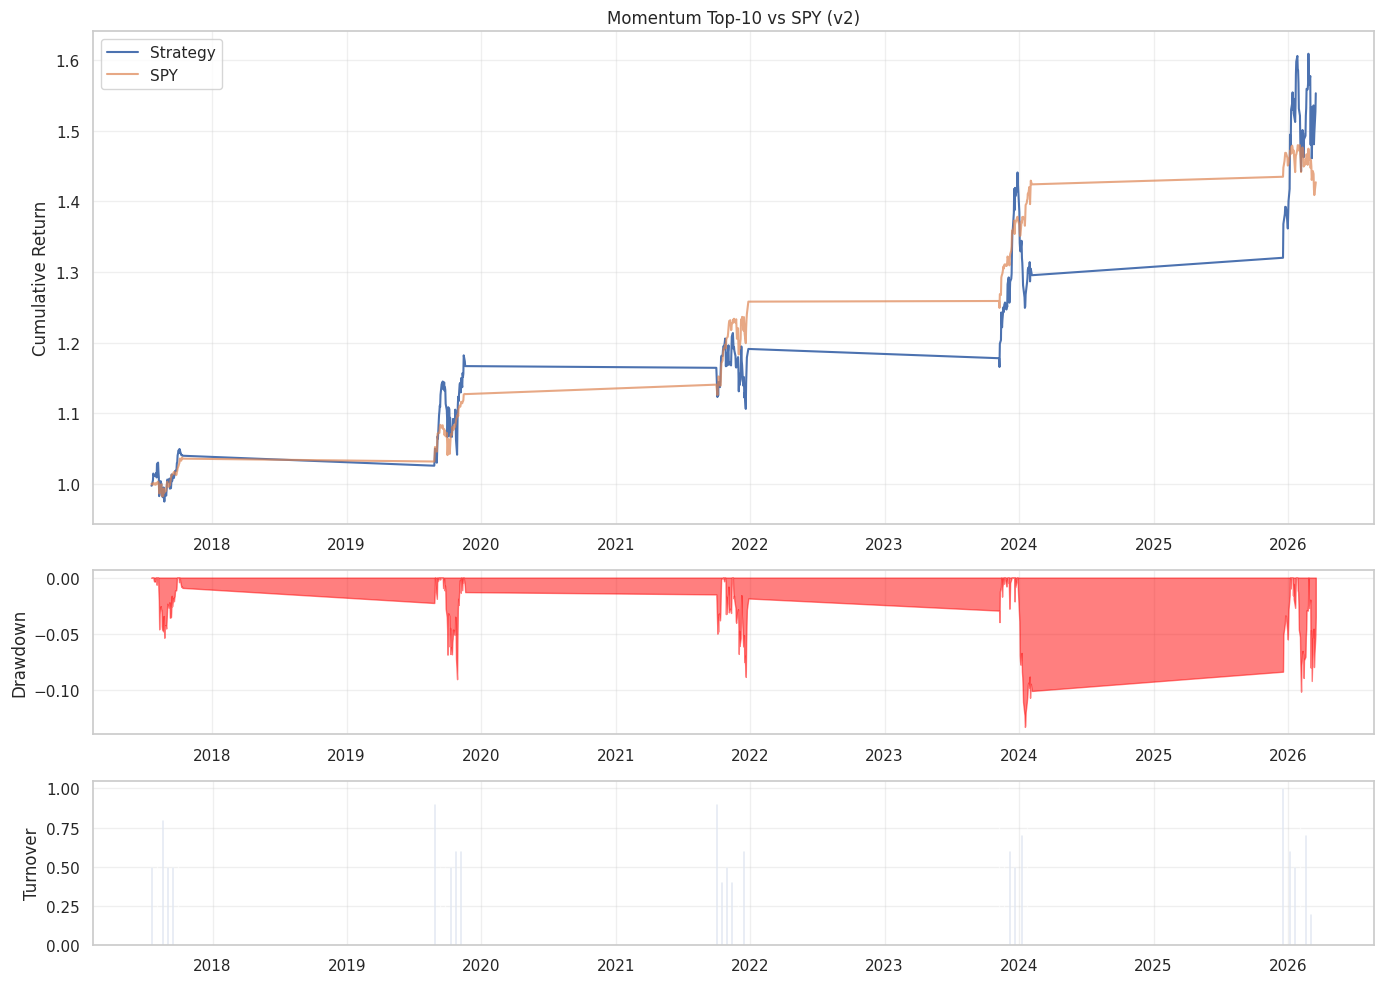

In [12]:
# Equity curve — Top 10 vs SPY
spy_ret_aligned = spy_daily_ret.reindex(bt_results.index).fillna(0)
plot_equity_curve(bt_results, spy_ret_aligned, title="Momentum Top-10 vs SPY (v2)")
plt.savefig("../output/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

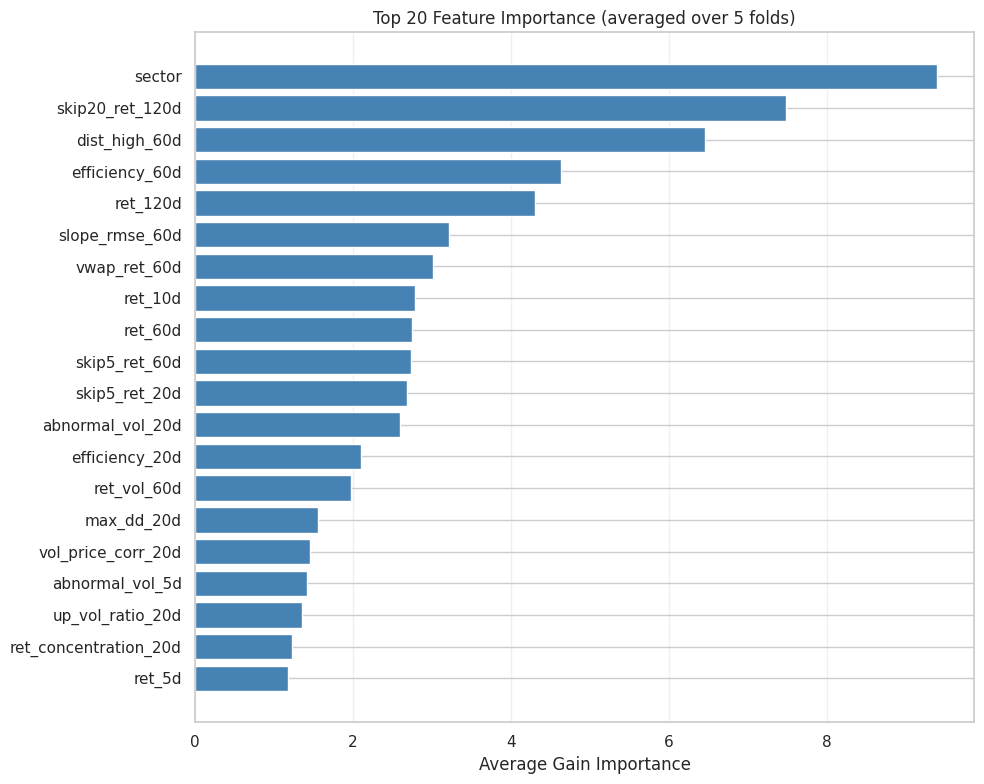

In [14]:
feature_names = features.columns.tolist()
plot_feature_importance(models, feature_names, top_n=20)
plt.savefig("../output/equity_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 总结

**v2 特征体系**: 5 组 25 个纯量价特征，无行业信息
- 基础动量 / skip 动量 / 路径质量 / 风险调整动量 / 量价交互

**判断标准**:
- Mean IC > 0.02 且 ICIR > 0.5 → 信号有意义
- 分层回测 Q5 > Q4 > ... > Q1 → 模型有区分力
- Top 10/20/30 都有超额 → 信号稳定

**实验记录**:
- 标签时间尺度扫描（5/10/20/40/60d）：10d 的 IC/ICIR 最优
- 去掉 sector categorical feature 后 IC 从 0.011 升至 0.014，确认量价因子本身有效